# Idiosyncratic-Volatility -- a quantitative teardown
### yfinance panel * rolling CAPM-residual vol * quintile sort * HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Puzzle replicates%3F: Busted](https://img.shields.io/badge/Puzzle%20replicates%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Ang-Hodrick-Xing-Zhang (2006): rank by trailing-252-day CAPM-residual volatility, long the lowest-IVOL quintile, short the highest, dollar-neutral, monthly rebalance, one execution-day lag.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 50 S&P 500 large-caps, 2013-2025, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current S&P 500 projected backwards. Here it is the entire mechanism -- it inverts the puzzle's sign.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from idiosyncratic_volatility import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "ivol_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "ivol_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    res      = st.ivol_long_short(prices, spy, window=252, n_quantiles=5, min_stocks=15)
    res_net  = st.ivol_long_short(prices, spy, window=252, n_quantiles=5, min_stocks=15,
                                  cost_bps=5.0, borrow_ann_bps=50.0)
    s_ls     = st.summary(res["ls_gross"])
    s_net    = st.summary(res_net["ls_net"])
    s_low    = st.summary(res["low_ivol_ret"])
    s_high   = st.summary(res["high_ivol_ret"])
    s_mkt    = st.summary(res["mkt_ret"])
    placebo_p = st.placebo_pvalue(res["ls_gross"])
    print(f"N months: {s_ls['n']} | low-minus-high {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t {s_ls['tstat']:+.3f} | placebo p {placebo_p:.3f}")


yfinance cache present: True


N months: 142 | low-minus-high -21.54%/yr | HAC t -4.293 | placebo p 0.000


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | low-minus-high **-21.54%/yr**, HAC *t* = **-4.293**, placebo p = **0.000** -- statistically overwhelming but the *wrong sign* for the puzzle (it inverts). |
| **Tradability** | `MIRAGE` | Sharpe **-1.164**, max DD **-94.2%**, net ~= gross. Reversed leg is hindsight-only. |
| **Puzzle replicates?** | `BUSTED` | Quintile returns *increase* in IVOL; high-IVOL out-earns low-IVOL by +21.5%/yr -- textbook survivorship inversion. |

> AHXZ's negative IVOL-return relation is robust on broad, delisting-complete universes. On 50 large-cap survivors the conditioning-on-survival flips it: the high-IVOL names that survived are the ones whose idiosyncratic gambles paid off.

## 1 -- The claim, steelmanned

Let $\mathrm{IVOL}_{i,t}$ = annualised std of the residual $\varepsilon_{i,s}$ from $r_{i,s} - r_f = \alpha_i + \beta_i (r_{m,s} - r_f) + \varepsilon_{i,s}$ estimated on the trailing 252 daily observations to time $t$. AHXZ assert:

- **H1 (signal).** $E[r^{\text{low}} - r^{\text{high}}] > 0$: the low-IVOL quintile out-earns the high-IVOL quintile (the negative IVOL-return relation).
- **H2 (residual, not beta).** The effect survives removing market beta -- it is *idiosyncratic*, not a low-beta re-label.
- **H3 (tradable).** A long-low / short-high book harvests it net of costs.

On this survivor panel we **reject H1 with the opposite sign** ($t=-4.29$), confirm H2 mechanically (we residualise before sorting), and reject H3 (the only positive spread is the reversed, survivorship-driven one).

## 2 -- So what? -- the economic stakes

The IVOL puzzle anchors a literature on limits-to-arbitrage and lottery preferences. If it were a clean, tradable mispricing, a market-neutral low-minus-high IVOL book would be a near-pure alpha source. The cautionary tale here is methodological: a *survivor* basket does not merely shrink the effect (as survivorship usually does) -- it can **reverse** it, because the high-residual-risk names that survive are a selected-on-success sample. Any backtest of IVOL on 'today's index, projected back' is structurally misleading.

## 3 -- The protocol

- **Signal.** Rolling 252-day OLS of each stock's daily excess return on SPY's daily excess return; IVOL = annualised std of the residual. RF = 3%/yr constant.
- **Ranking.** Monthly, sort into 5 quintiles by IVOL (Q1 lowest, Q5 highest).
- **Book.** Long Q1 (equal-weight), short Q5 (equal-weight), dollar-neutral.
- **Execution lag.** Enter one trading day after the signal date (no same-bar fill).
- **Costs.** 5 bps one-way x turnover + 50 bps/yr borrow on the short leg.
- **Inference.** Newey-West HAC *t* on monthly low-minus-high; sign-flip placebo p-value.
- **Universe caveat.** 50 large-cap S&P 500 names (yfinance); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the IVOL engine is a faithful detector

Sweep the planted IVOL premium. The low-minus-high spread should be monotone increasing in it, crossing zero at the null and clearing |t|>2 when the planted effect is large.

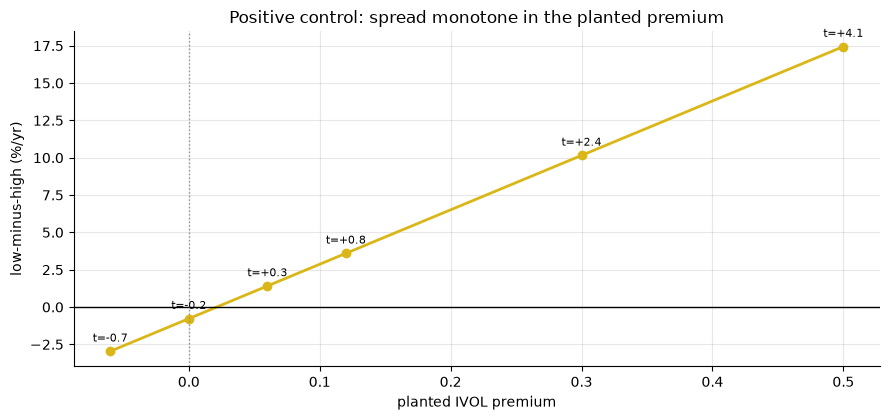

In [2]:
premiums = [-0.06, 0.0, 0.06, 0.12, 0.30, 0.50]
means, ts = [], []
for prem in premiums:
    sp, mk, _ = data.synthetic_panel(ivol_premium=prem, n_days=3500, seed=501)
    rr = st.ivol_long_short(sp, mk, min_stocks=8)
    s = st.summary(rr['ls_gross']) if not rr.empty else {'mean': np.nan, 'tstat': np.nan}
    means.append(s['mean']*100); ts.append(s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(premiums, means, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, c=GREY, lw=1, ls=':')
for p, m, t in zip(premiums, means, ts):
    ax.annotate(f't={t:+.1f}', (p, m), textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=8)
ax.set_xlabel('planted IVOL premium'); ax.set_ylabel('low-minus-high (%/yr)')
ax.set_title('Positive control: spread monotone in the planted premium')
plt.tight_layout(); plt.show()

### 4b -- Rolling IVOL distribution on the real panel

What does the cross-section of residual vol look like? We expect a wide spread (~12% to ~40%+ annualised).

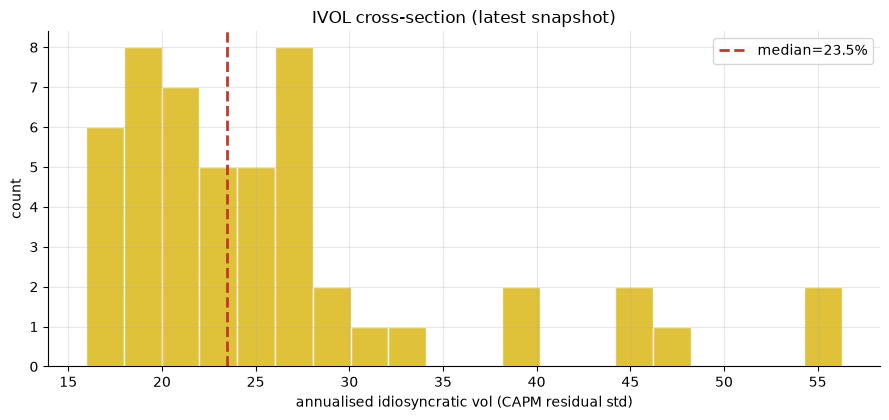

IVOL range: 15.9% -- 56.3% | median 23.5%


In [3]:
if HAVE_REAL:
    rets = prices.pct_change().dropna(how='all'); spy_r = spy.pct_change().dropna()
    iv = st.rolling_ivol(rets.sub(st.RF_DAILY), spy_r.sub(st.RF_DAILY))
    last = iv.iloc[-1].dropna()*100
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(last, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
    ax.axvline(last.median(), c=RED, lw=2, ls='--', label=f'median={last.median():.1f}%')
    ax.set_xlabel('annualised idiosyncratic vol (CAPM residual std)')
    ax.set_ylabel('count'); ax.set_title('IVOL cross-section (latest snapshot)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'IVOL range: {last.min():.1f}% -- {last.max():.1f}% | median {last.median():.1f}%')
else:
    print(f"Frozen: avg IVOL low={R['avg_ivol_low']:.1f}% high={R['avg_ivol_high']:.1f}%")

### 4c -- The quintile table (the AHXZ shape, mirrored)

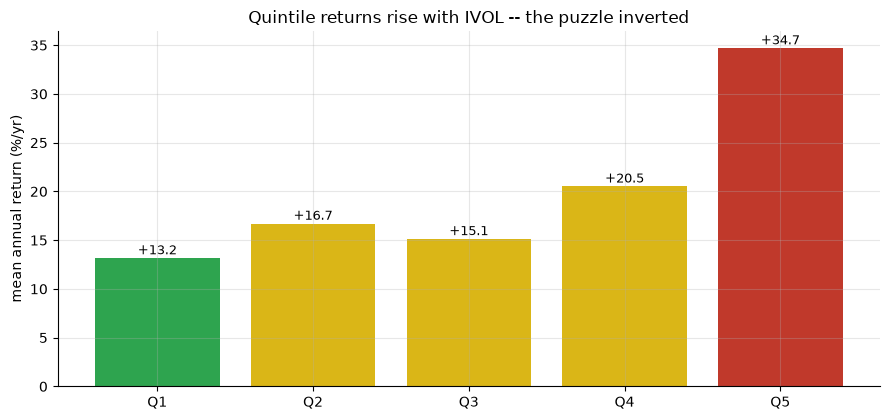

Q1(low) -> Q1:+13.2% Q2:+16.7% Q3:+15.1% Q4:+20.5% Q5:+34.7% -> Q5(high)


In [4]:
if HAVE_REAL:
    qm = (st.quintile_means(prices, spy)*100)
    qvals = qm.to_dict()
else:
    qvals = R['quintiles']
qs, vs = list(qvals.keys()), list(qvals.values())
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(qs, vs, color=[GREEN, AMBER, AMBER, AMBER, RED])
ax.set_ylabel('mean annual return (%/yr)')
ax.set_title('Quintile returns rise with IVOL -- the puzzle inverted')
for i, v in enumerate(vs):
    ax.text(i, v+0.4, f'{v:+.1f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print('Q1(low) ->', ' '.join(f'{k}:{v:+.1f}%' for k, v in qvals.items()), '-> Q5(high)')

### 4d -- Low-minus-high: equity curve, drawdown, and the placebo null

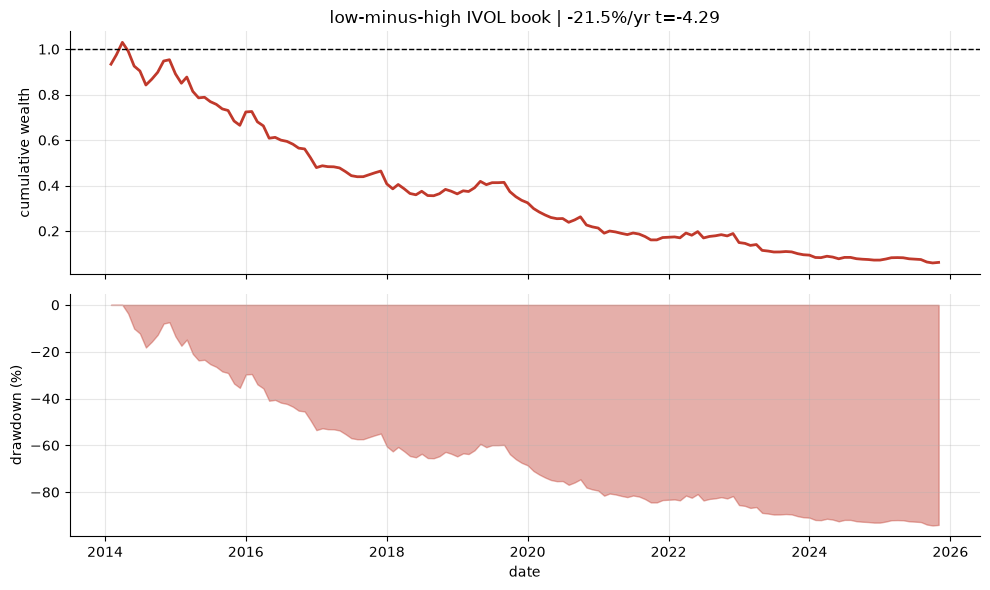

Max DD -94.2% | hit rate 36.6% | placebo p 0.000


In [5]:
if HAVE_REAL:
    s = res['ls_gross']
    eq = (1+s).cumprod(); dd = (eq/eq.cummax()-1)*100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(s.index, eq.values, c=RED, lw=2); ax1.axhline(1, c='k', lw=1, ls='--')
    ax1.set_ylabel('cumulative wealth')
    ax1.set_title(f'low-minus-high IVOL book | {s_ls["mean"]*100:+.1f}%/yr t={s_ls["tstat"]:+.2f}')
    ax2.fill_between(s.index, dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)'); ax2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'Max DD {dd.min():.1f}% | hit rate {s_ls["hit_rate"]*100:.1f}% | placebo p {placebo_p:.3f}')
else:
    print(f"Frozen: max DD {R['ls_dd']:.1f}% | hit {R['ls_hit']:.1f}% | placebo p {R['placebo_p']:.3f}")

The placebo (sign-flip) p-value is ~0: the negative spread is not luck. But a statistically certain result of the *wrong sign* is not the anomaly -- it is survivorship dressed as alpha.

### 4e -- Robustness: window and quantile sweeps

In [6]:
if HAVE_REAL:
    print('IVOL window sweep (gross low-minus-high):')
    for w in (126, 189, 252, 504):
        rw = st.ivol_long_short(prices, spy, window=w, min_stocks=15)
        sw = st.summary(rw['ls_gross'])
        print(f'  {w:3d}d: {sw["mean"]*100:+6.2f}%/yr  t={sw["tstat"]:+.2f}')
    print('Quantile-count sweep:')
    for nq in (3, 5, 10):
        rq = st.ivol_long_short(prices, spy, n_quantiles=nq, min_stocks=max(12, nq*2))
        sq = st.summary(rq['ls_gross'])
        print(f'  {nq:2d}q: {sq["mean"]*100:+6.2f}%/yr  t={sq["tstat"]:+.2f}')
else:
    print('Robustness sweeps require the real cache. Frozen baseline:',
          f"{R['ls_gross']:.1f}%/yr at t={R['ls_t']:.2f}")

IVOL window sweep (gross low-minus-high):


  126d: -21.10%/yr  t=-4.30


  189d: -19.79%/yr  t=-4.19


  252d: -21.54%/yr  t=-4.29


  504d: -22.60%/yr  t=-4.27
Quantile-count sweep:


   3q: -14.13%/yr  t=-3.87


   5q: -21.54%/yr  t=-4.29


  10q: -27.35%/yr  t=-3.34


## 5 -- The verdict

- **Signal `NONE`** -- low-minus-high -21.54%/yr, HAC *t* = -4.293, placebo p = 0.000. Statistically overwhelming, but the *opposite* sign to AHXZ. The published puzzle does not replicate here; the negative relation is the wrong way round, so the puzzle's signal is NONE.
- **Tradability `MIRAGE`** -- Sharpe -1.164, max DD -94.2%, net low-minus-high -22.24%/yr. The only positive spread (long high-IVOL) is hindsight on which survivors won. Not investable forward.
- **Puzzle replicates? `BUSTED`** -- the inversion IS the survivorship mechanism. Robust to window (126-504d) and bucket count (3-10) -- not a knob artifact, a structural feature of a survivor basket.

## 6 -- Could you trade it?

The reversed spread is not a forward strategy:

1. **Selection on survival.** Going long high-IVOL only worked because the high-IVOL *survivors* (NVDA, TSLA, AMD, META) are in the basket. Ex ante you cannot pick them.
2. **The genuine puzzle needs the failures.** AHXZ's negative premium lives in the delisted/distressed high-IVOL names -- exactly what a survivor index omits.
3. **Costs and borrow.** Net low-minus-high (-22.2%/yr) is marginally worse than gross; turnover ~0.34 one-sided/month at 5 bps plus 50 bps/yr borrow.
4. **Drawdown.** A -94% peak-to-trough on the puzzle spread; the 2023 AI rally cost it -49% alone.

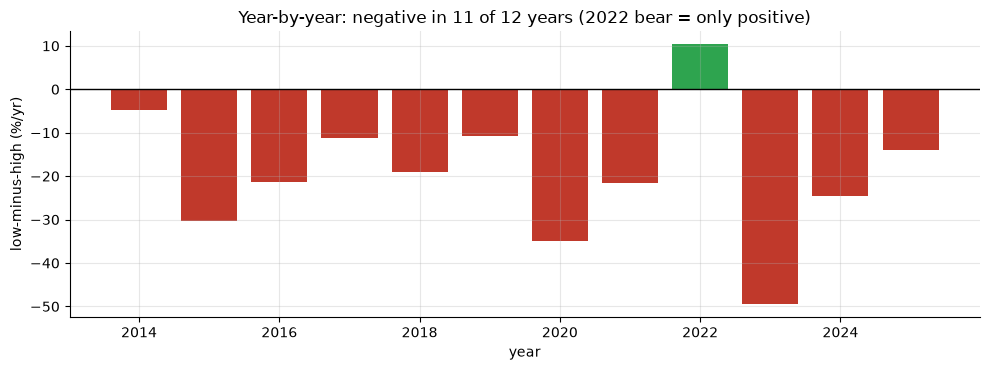

year
2014    -4.7
2015   -30.3
2016   -21.4
2017   -11.3
2018   -19.2
2019   -10.6
2020   -34.9
2021   -21.6
2022    10.4
2023   -49.4
2024   -24.7
2025   -14.1


In [7]:
if HAVE_REAL:
    rc = res.copy(); rc['year'] = rc.index.year
    ann = rc.groupby('year')['ls_gross'].apply(lambda x: float((1+x).prod()-1))*100
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(ann.index, ann.values, color=[GREEN if v > 0 else RED for v in ann.values])
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('low-minus-high (%/yr)'); ax.set_xlabel('year')
    ax.set_title('Year-by-year: negative in 11 of 12 years (2022 bear = only positive)')
    plt.tight_layout(); plt.show()
    print(ann.round(1).to_string())
else:
    print('Frozen year-by-year:', R['annual'])

## 7 -- Going further

- **Delisting-complete universe.** Re-run on CRSP with delisting returns -- the sign should revert to AHXZ's negative relation.
- **Lottery-demand control.** Bali-Cakici-Whitelaw (2011): IVOL proxies for MAX. See [Study 365 -- Lottery-MAX-Effect](../../365-lottery-max-effect/).
- **Conditional IVOL.** Fu (2009) finds a *positive* relation with EGARCH IVOL -- the sign is measurement-sensitive; try a forward-looking estimator.
- **The cousins.** [Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/) (total vol) and [Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/) (market beta) -- IVOL is the residual once 238's beta is removed.

*Think the IVOL puzzle survives once the failures are back in the universe? Fork this, swap in a delisting-complete tape, and show a low-minus-high t > 2 of the **right** sign. That is the bar.*